In [19]:
!pip install seaborn

# Validación básica de calidad de datos:

- Valores nulos
- Longitud promedio de reseñas
- Distribución temporal de reseñas

## Productos

In [41]:
import pandas as pd

product_data = pd.read_csv('../data/raw/csv/pd_info.csv')
product_data.head()

,pd_id,keyword,brand,size_and_item,category,price,love_count,reviews_count,Name,Description,AverageOverallRating,FirstSubmissionTime,LastSubmissionTime
0,P513098,Hyaluronic Acid,Act+Acre,1 oz / 30 mL,"2788917 1 oz / 30 mL, Scalp Treatments, Hair S...",$24.00,14704,209,Daily Hydro? Scalp Serum with Hyaluronic Acid ...,"What it is: A daily leave-on serum, formulated...",4.712919,2024-08-10T01:10:33.000+00:00,2026-03-06T00:00:53.000+00:00
1,P513880,Niacinamide,Act+Acre,2.2 oz / 65 ml,"2766558 2.2 oz / 65 ml, Scalp Treatments, Hair...",$68.00,3477,144,4% Niacinamide Scalp Serum For Oily Scalp + Hair,What it is: A pH-optimized leave-on scalp seru...,4.743056,2024-09-15T00:47:14.000+00:00,2025-10-12T18:26:21.000+00:00
2,P515494,Niacinamide,AESTURA,2.71 oz / 80 mL,"2844942 2.71 oz / 80 mL, Face Creams, Moisturi...",$32.00,71324,497,ATOBARRIER365 Cream Moisturizer with Ceramides...,"What it is: A dermatologist-tested, rich cream...",4.497992,2025-02-01T14:15:47.000+00:00,2026-03-09T00:58:17.000+00:00
3,P520094,Hyaluronic Acid,AESTURA,2.02 fl oz/60 ml,"2929248 1.35 fl. Oz./40 ml, Face Serums, Treat...",$32.00,2011,171,A-CICA365 Soothing Redness Relief Face Serum p...,What it is: A lightweight serum with proprieta...,4.900585,2026-02-11T00:08:19.000+00:00,2026-03-06T14:10:37.000+00:00
4,P515497,Niacinamide,AESTURA,5.07 oz / 150 mL,"2844926 5.07 oz / 150 mL, Face Creams, Moistur...",$32.00,23960,268,ATOBARRIER365 Lightweight Face Lotion Moisturi...,"What it is: A dermatologist-tested, lightweigh...",4.735075,2025-02-01T11:32:29.000+00:00,2026-03-06T18:29:59.000+00:00


In [42]:
# valores nulos
product_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pd_id                 10 non-null     object 
 1   keyword               10 non-null     object 
 2   brand                 10 non-null     object 
 3   size_and_item         10 non-null     object 
 4   category              10 non-null     object 
 5   price                 10 non-null     object 
 6   love_count            10 non-null     int64  
 7   reviews_count         10 non-null     int64  
 8   Name                  10 non-null     object 
 9   Description           10 non-null     object 
 10  AverageOverallRating  10 non-null     float64
 11  FirstSubmissionTime   10 non-null     object 
 12  LastSubmissionTime    10 non-null     object 
dtypes: float64(1), int64(2), object(10)
memory usage: 1.1+ KB


### modificando price y size and item 

In [43]:
# resumen por producto
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 1. Clean the price column (remove '$' and convert to float)
if product_data['price'].dtype == 'O':  # If it's an object/string
    product_data['price'] = product_data['price'].str.replace('$', '', regex=False).astype(float)

# 2. Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# 1. Improved regex to handle 'fl oz', 'fl. oz', and 'oz'
# We use case-insensitive matching to handle 'OZ', 'Oz', or 'oz'
regex_pattern = r'(\d+\.?\d*)\s*(?:fl\.?\s*oz|oz)'

product_data['size_oz'] = (
    product_data['size_and_item']
    .str.extract(regex_pattern, flags=re.IGNORECASE)[0] # Extract first group
    .astype(float)
)

product_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pd_id                 10 non-null     object 
 1   keyword               10 non-null     object 
 2   brand                 10 non-null     object 
 3   size_and_item         10 non-null     object 
 4   category              10 non-null     object 
 5   price                 10 non-null     float64
 6   love_count            10 non-null     int64  
 7   reviews_count         10 non-null     int64  
 8   Name                  10 non-null     object 
 9   Description           10 non-null     object 
 10  AverageOverallRating  10 non-null     float64
 11  FirstSubmissionTime   10 non-null     object 
 12  LastSubmissionTime    10 non-null     object 
 13  size_oz               10 non-null     float64
dtypes: float64(3), int64(2), object(9)
memory usage: 1.2+ KB


### Distribución de las variables númericas por producto

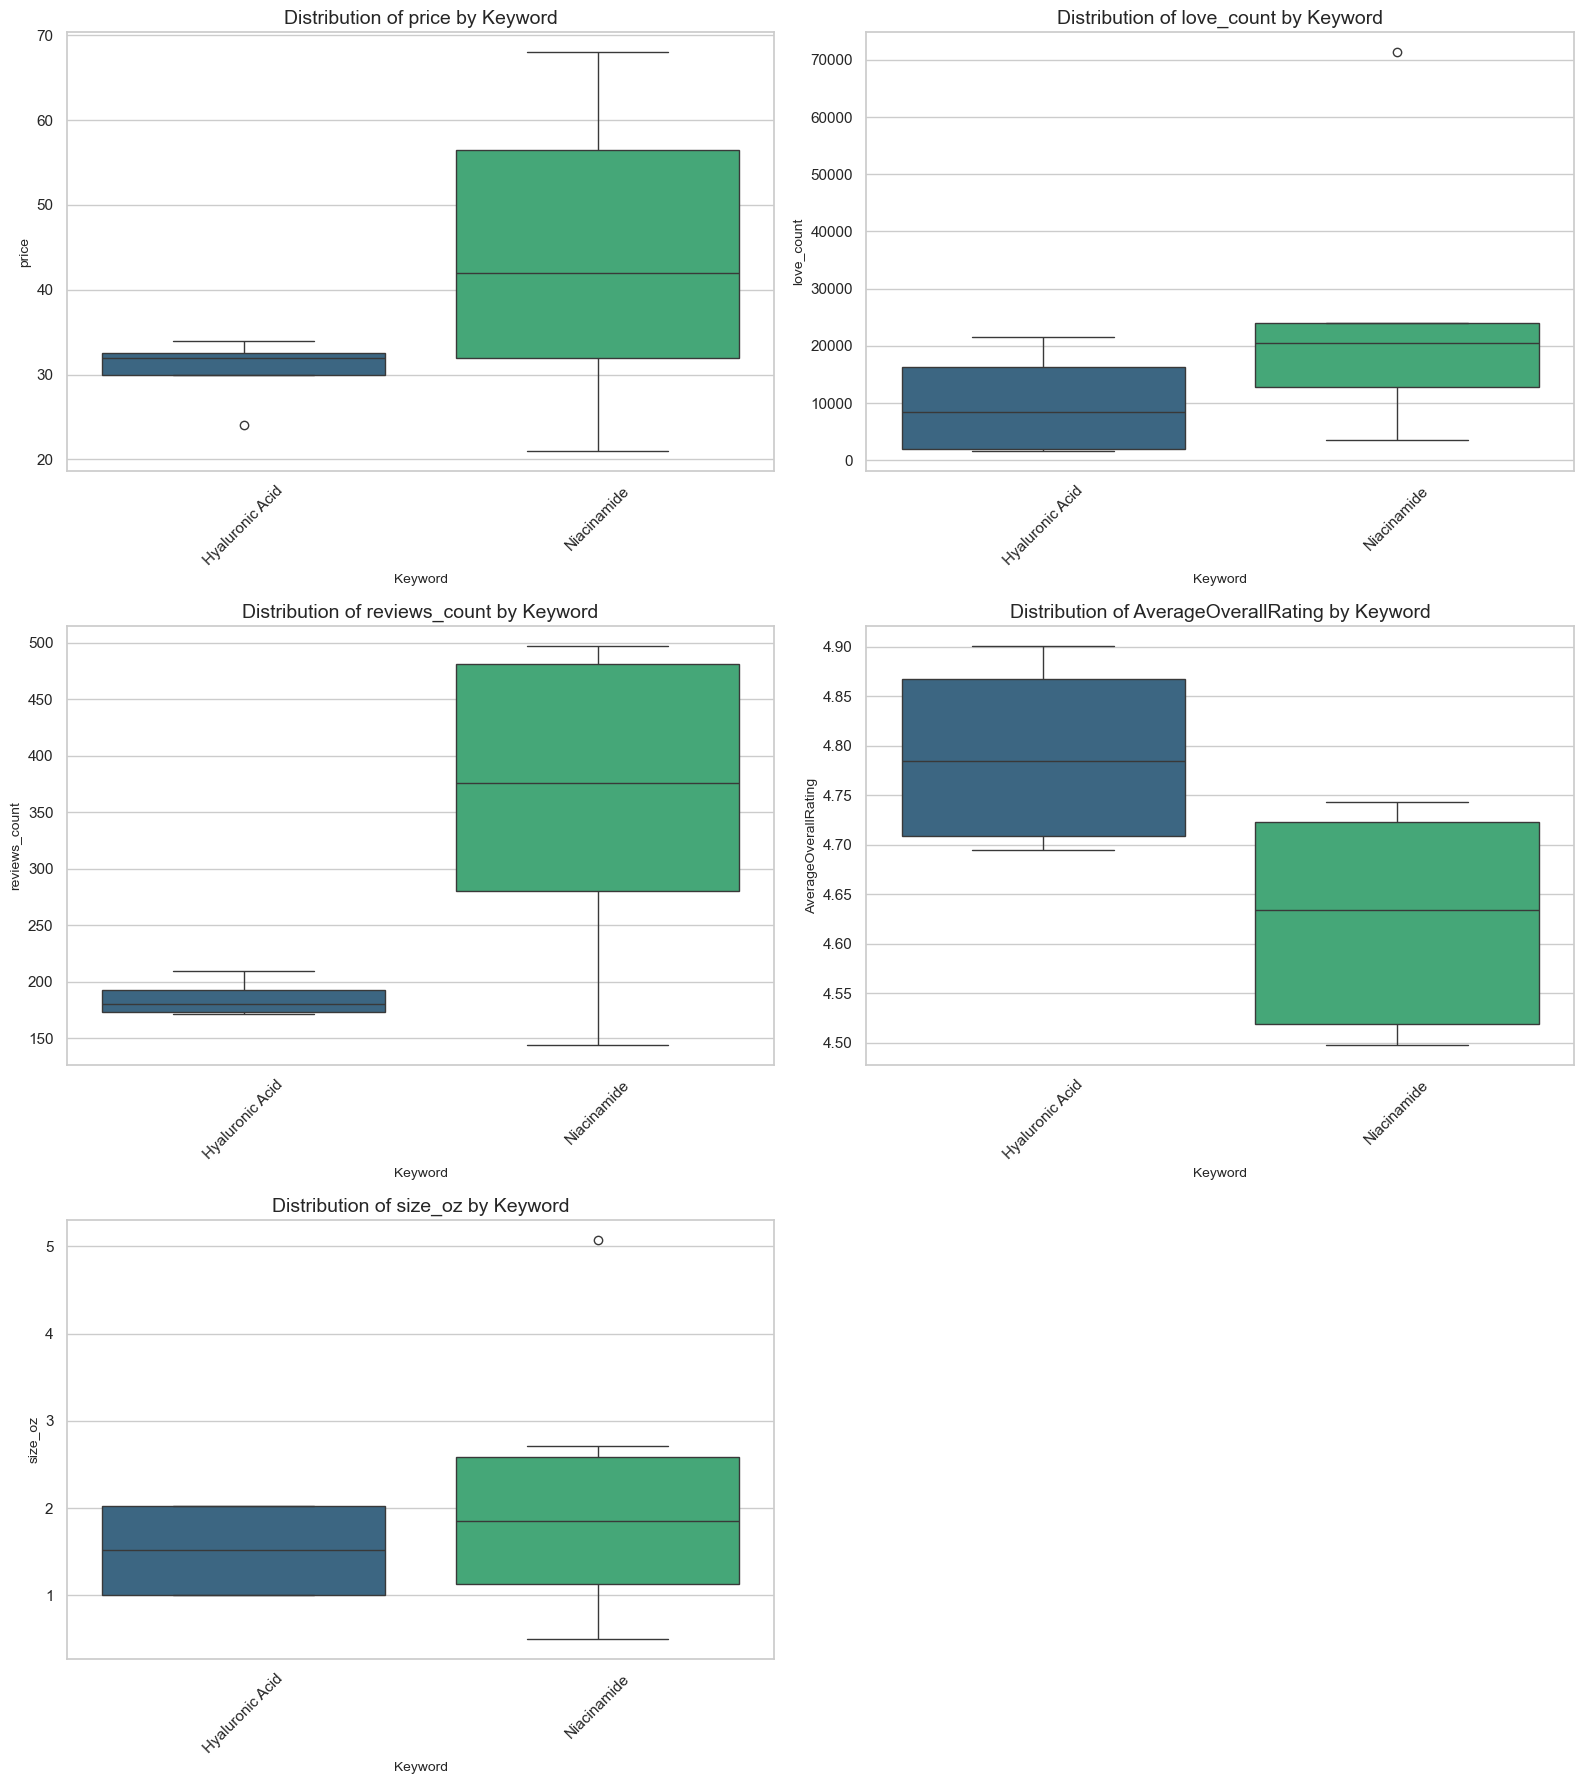

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 1. Cleaning & Robust Extraction
# Clean Price (in case it contains $)
if product_data['price'].dtype == 'O':
    product_data['price'] = product_data['price'].astype(str).str.replace('$', '', regex=False).astype(float)

# Robust Regex to capture "oz", "fl oz", or "fl. oz"
# Example input: "2.02 fl oz/60 ml" -> Output: 2.02
regex_pattern = r'(\d+\.?\d*)\s*(?:fl\.?\s*oz|oz)'
product_data['size_oz'] = (
    product_data['size_and_item']
    .str.extract(regex_pattern, flags=re.IGNORECASE)[0]
    .astype(float)
)

# 2. Setup Plotting Environment (5 metrics = 3 rows, 2 columns)
metrics = ['price', 'love_count', 'reviews_count', 'AverageOverallRating', 'size_oz']
sns.set_theme(style="whitegrid")

# Create a 3x2 grid (6 total slots)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten() # Flatten the 2D array for easy iteration

# 3. Generate Box Plots
for i, metric in enumerate(metrics):
    sns.boxplot(
        ax=axes[i], 
        data=product_data, 
        x='keyword', 
        y=metric, 
        palette='viridis',
        hue='keyword'
    )
    
    axes[i].set_title(f'Distribution of {metric} by Keyword', fontsize=14)
    axes[i].set_xlabel('Keyword', fontsize=10)
    axes[i].set_ylabel(metric, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    
    # Clean up: Remove legend if hue created one
    leg = axes[i].get_legend()
    if leg is not None:
        leg.remove()

# 4. Hide the unused 6th subplot
if len(metrics) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# Reviews

In [45]:
reviews_data = pd.read_csv('../data/raw/csv/review_data.csv')
reviews_data.head()

,pd_id,AuthorId,Rating,Title,ReviewText,Helpfulness,SubmissionTime,IsRecommended,eyeColor,hairColor,skinTone,skinType
0,P513098,34708283257,5,SO good!,"I have always suffered with a dry scalp and, a...",1.0,2026-02-06T15:34:00.000+00:00,True,NaN,black,NaN,NaN
1,P513098,2175802834,5,NaN,This thing is a miracle in a bottle. It finall...,1.0,2026-02-01T14:09:55.000+00:00,True,NaN,brown,NaN,NaN
2,P513098,9099093786,4,saves me from the post-wash dry flaky scalp,I bought this because my scalp gets very dry a...,1.0,2025-11-01T04:23:00.000+00:00,True,NaN,black,NaN,NaN
3,P513098,2457522697,1,NaN,Didn’t any difference using this product and i...,1.0,2025-08-26T13:50:37.000+00:00,False,NaN,brown,NaN,NaN
4,P513098,12903380383,5,NaN,So far this has helped! My roots look so hydra...,1.0,2025-07-08T12:06:44.000+00:00,True,brown,black,deep,comboSk


In [46]:
reviews_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2901 entries, 0 to 2900
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pd_id           2901 non-null   object 
 1   AuthorId        2901 non-null   int64  
 2   Rating          2901 non-null   int64  
 3   Title           1996 non-null   object 
 4   ReviewText      2900 non-null   object 
 5   Helpfulness     1341 non-null   float64
 6   SubmissionTime  2901 non-null   object 
 7   IsRecommended   2901 non-null   bool   
 8   eyeColor        1920 non-null   object 
 9   hairColor       1333 non-null   object 
 10  skinTone        1505 non-null   object 
 11  skinType        2572 non-null   object 
dtypes: bool(1), float64(1), int64(2), object(8)
memory usage: 252.3+ KB


### Longitud promedio de las reviews

The average review length is: 314.13 characters


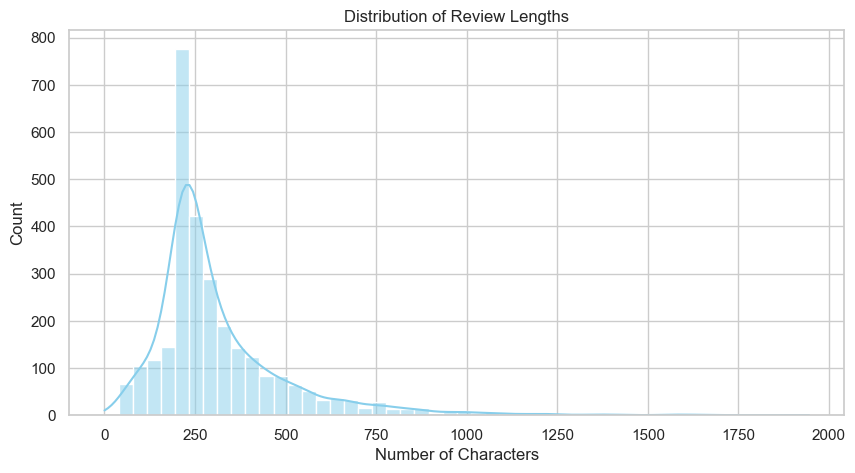

In [47]:
# Handle the single missing ReviewText by filling with an empty string
reviews_data['ReviewText'] = reviews_data['ReviewText'].fillna('')

# Calculate length of each review
reviews_data['review_length'] = reviews_data['ReviewText'].apply(len)

# Calculate the average
avg_length = reviews_data['review_length'].mean()

print(f"The average review length is: {avg_length:.2f} characters")

# Optional: Visualize the distribution of lengths
plt.figure(figsize=(10, 5))
sns.histplot(reviews_data['review_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Characters')
plt.show()

### Distribución temporal de reviews

C:\Users\danie\AppData\Local\Temp\ipykernel_31904\1833162401.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  reviews_data['year_month'] = reviews_data['SubmissionTime'].dt.to_period('M')


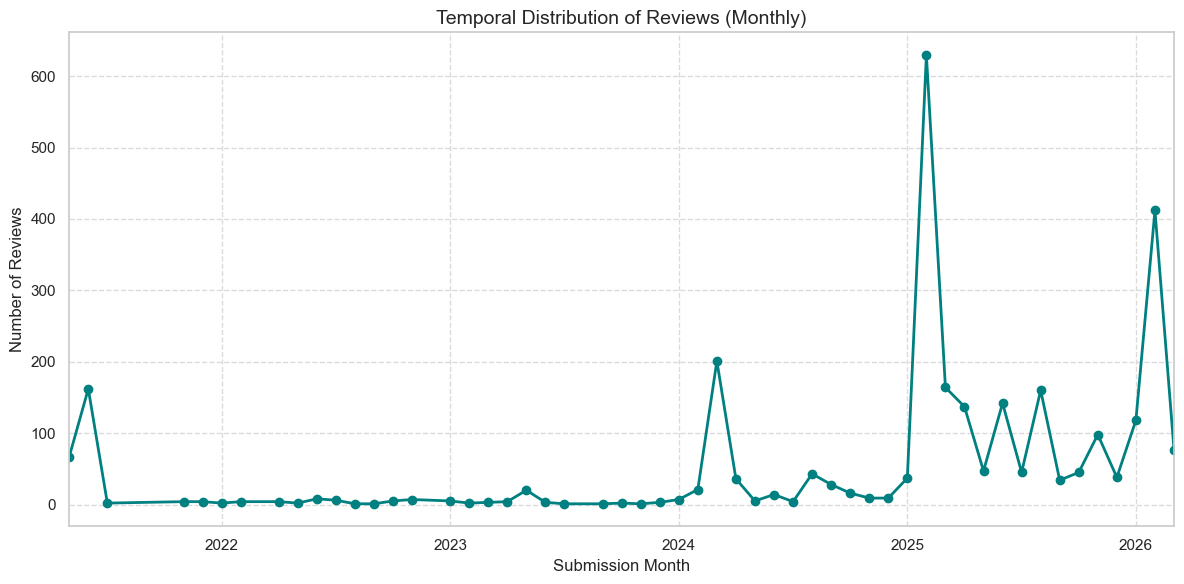

In [36]:
# 1. Convert to datetime
# format='ISO8601' handles the 'T' and offset format in your data
reviews_data['SubmissionTime'] = pd.to_datetime(reviews_data['SubmissionTime'], utc=True)

# 2. Extract Year-Month for a cleaner distribution
reviews_data['year_month'] = reviews_data['SubmissionTime'].dt.to_period('M')

# 3. Count reviews per month
temporal_dist = reviews_data.groupby('year_month').size()

# 4. Plot the distribution
plt.figure(figsize=(12, 6))
temporal_dist.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Temporal Distribution of Reviews (Monthly)', fontsize=14)
plt.xlabel('Submission Month', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Numero de reviews por item

Top 10 Products by Review Count:
pd_id
P515486    498
P515494    498
P472302    435
P510865    317
P515497    268
P513098    209
P515491    187
P520090    174
P520094    171
P513880    144
dtype: int64


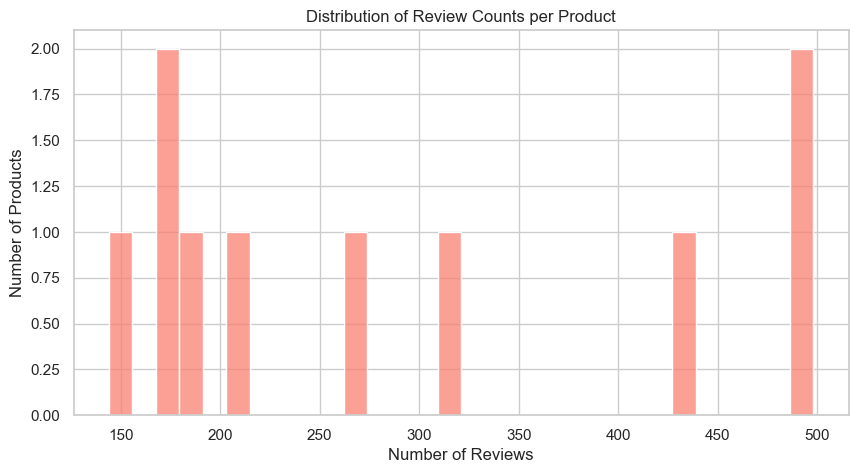

In [40]:
# Group by product ID and count occurrences
reviews_per_product = reviews_data.groupby('pd_id').size().sort_values(ascending=False)

# Display the top 10 products with the most reviews
print("Top 10 Products by Review Count:")
print(reviews_per_product.head(10))

# Optional: Visualize the distribution of review counts
plt.figure(figsize=(10, 5))
sns.histplot(reviews_per_product, bins=30, kde=False, color='salmon')
plt.title('Distribution of Review Counts per Product')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Products')
plt.show()

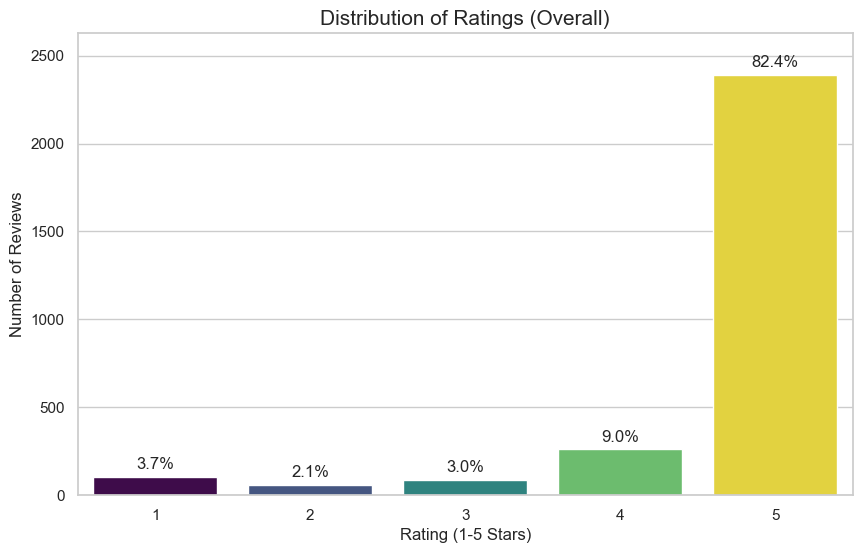

In [38]:
# 1. Calculate the percentage of each rating
rating_counts = reviews_data['Rating'].value_counts(normalize=True).sort_index() * 100

# 2. Plot the distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=reviews_data, x='Rating', palette='viridis', hue='Rating', legend=False)

# Add percentage labels on top of bars
ax = plt.gca()
for i, p in enumerate(ax.patches):
    ax.annotate(f'{rating_counts.iloc[i]:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.title('Distribution of Ratings (Overall)', fontsize=15)
plt.xlabel('Rating (1-5 Stars)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.ylim(0, reviews_data['Rating'].value_counts().max() * 1.1) # Add space for labels
plt.show()